## Khai báo thư viện và cấu hình Reproducibility

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cpu


## Tải dữ liệu, tiền xử lý và chia tập Train/Val/Test

In [ ]:
df_products = pd.read_csv("../DATA/product_info.csv")
df_reviews = pd.read_csv("../DATA/reviews.csv", low_memory=False, dtype={'author_id': str, 'product_id': str})

print(f"Kích thước ban đầu - Products: {df_products.shape} | Reviews: {df_reviews.shape}")

# Ép kiểu khóa liên kết product_id về dạng chuỗi và ghép nối (Inner Join)
df_products['product_id'] = df_products['product_id'].astype(str)
df_reviews['product_id'] = df_reviews['product_id'].astype(str)

df_merged = pd.merge(df_reviews, df_products, on='product_id', suffixes=('_review', '_prod'))
print(f"Kích thước sau khi Merge: {df_merged.shape}")

# Xác định biến mục tiêu nhị phân: is_recommended (1.0: Đề xuất, 0.0: Không đề xuất)
TARGET_COL = 'is_recommended'
df_merged[TARGET_COL] = pd.to_numeric(df_merged[TARGET_COL], errors='coerce')
df_merged = df_merged.dropna(subset=[TARGET_COL])
df_merged[TARGET_COL] = df_merged[TARGET_COL].astype(int)

# Chọn lọc các thuộc tính số học và phân loại tiêu biểu của cả sản phẩm và người dùng
feature_cols = [
    # Đặc trưng người dùng & đánh giá (từ reviews.csv)
    'skin_type', 'skin_tone', 'eye_color', 'hair_color',
    'total_feedback_count', 'total_pos_feedback_count', 'total_neg_feedback_count',
    # Đặc trưng sản phẩm (từ product_info.csv)
    'loves_count', 'reviews', 'price_usd', 'value_price_usd',
    'primary_category', 'secondary_category',
    'online_only', 'out_of_stock', 'sephora_exclusive'
]
# Giữ lại các cột thực tế tồn tại trong dữ liệu
feature_cols = [c for c in feature_cols if c in df_merged.columns]
print(f"Danh sách {len(feature_cols)} đặc trưng được chọn đưa vào mô hình:")
print(feature_cols)

# Lấy mẫu ngẫu nhiên 60.000 bản ghi để tối ưu thời gian huấn luyện và cân đối bộ nhớ
if len(df_merged) > 60000:
    df_sample = df_merged[feature_cols + [TARGET_COL]].sample(n=60000, random_state=42).copy()
else:
    df_sample = df_merged[feature_cols + [TARGET_COL]].copy()

# Xử lý biến phân loại bằng category codes và điền giá trị khuyết thiếu số học
for col in feature_cols:
    if not pd.api.types.is_numeric_dtype(df_sample[col]):
        df_sample[col] = df_sample[col].astype('category').cat.codes
    else:
        df_sample[col] = df_sample[col].fillna(df_sample[col].median())

# Tách ma trận đặc trưng X và vector nhãn y
X = df_sample[feature_cols].values.astype(np.float32)
y = df_sample[TARGET_COL].values.astype(np.int64)

# Chia tập Train/Val/Test theo tỷ lệ 70% - 15% - 15%
N = len(X)
indices = np.random.permutation(N)
train_end = int(0.70 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Chuẩn hóa Z-score trên biến đặc trưng X (Chỉ fit trên tập Train)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8

X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

INPUT_DIM = X_train.shape[1]
print(f"\nSố chiều đặc trưng đầu vào (INPUT_DIM): {INPUT_DIM}")
print(f"Kích thước tập Train     : {X_train.shape[0]} mẫu (Tỷ lệ nhãn 1: {np.mean(y_train):.2%})")
print(f"Kích thước tập Validation: {X_val.shape[0]} mẫu")
print(f"Kích thước tập Test       : {X_test.shape[0]} mẫu")

## Đóng gói PyTorch Dataset và DataLoader

In [5]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số lượng mini-batches trên mỗi Epoch (Train): {len(train_loader)}")

Số lượng mini-batches trên mỗi Epoch (Train): 657


## Định nghĩa các kiến trúc mạng nơ-ron (Baseline MLP & Deeper MLP)

In [6]:
# Kiến trúc 1: Baseline MLP (d -> 64 -> 2)
class BaselinePreferenceMLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(64, 2)  # 2 Logits ngõ ra (Nhãn 0: Không thích, Nhãn 1: Đề xuất)
        
    def forward(self, x):
        h = self.relu(self.fc1(x))
        return self.fc_out(h)

    def get_representation(self, x):
        return self.relu(self.fc1(x))

# Kiến trúc 2: Deeper MLP (d -> 64 -> 32 -> 2)
class DeeperPreferenceMLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc_out = nn.Linear(32, 2)  # 2 Logits ngõ ra
        
    def forward(self, x):
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        return self.fc_out(h2)

    def get_representation(self, x):
        h1 = self.relu1(self.fc1(x))
        return self.relu2(self.fc2(h1))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số Baseline Preference MLP: {count_parameters(BaselinePreferenceMLP())}")
print(f"Tổng số tham số Deeper Preference MLP  : {count_parameters(DeeperPreferenceMLP())}")

Tổng số tham số Baseline Preference MLP: 1154
Tổng số tham số Deeper Preference MLP  : 3170


## Xây dựng hàm huấn luyện (Training Loop) và đánh giá (Evaluation)

In [7]:
def train_epoch_cls(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total_samples = 0.0, 0, 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total_samples += X_batch.size(0)
    return running_loss / total_samples, correct / total_samples

def evaluate_cls(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total_samples = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total_samples += X_batch.size(0)
    return running_loss / total_samples, correct / total_samples

def train_model_cls(model, train_loader, val_loader, criterion, optimizer, epochs=40, device=device):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(epochs):
        t_loss, t_acc = train_epoch_cls(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate_cls(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Loss: {t_loss:.4f} - Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} - Acc: {v_acc:.4f}")
    return history

## Thực nghiệm

In [8]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 40

# --- Thực nghiệm 1: Baseline MLP (Adam, lr=0.001) ---
print("\n>>> Thực nghiệm 1: Baseline Preference MLP (Adam) <<<")
set_seed(42)
model_exp1 = BaselinePreferenceMLP().to(device)
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
history_exp1 = train_model_cls(model_exp1, train_loader, val_loader, criterion, optimizer_exp1, epochs=EPOCHS)
print(f"Exp 1 Final Val Acc: {history_exp1['val_acc'][-1]:.4f}")

# --- Thực nghiệm 2: Deeper MLP (Adam, lr=0.001) ---
print("\n>>> Thực nghiệm 2: Deeper Preference MLP (Adam) <<<")
set_seed(42)
model_exp2 = DeeperPreferenceMLP().to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)
history_exp2 = train_model_cls(model_exp2, train_loader, val_loader, criterion, optimizer_exp2, epochs=EPOCHS)
print(f"Exp 2 Final Val Acc: {history_exp2['val_acc'][-1]:.4f}")

# --- Thực nghiệm 3: Deeper MLP (SGD Momentum, lr=0.01) ---
print("\n>>> Thực nghiệm 3: Deeper Preference MLP (SGD Momentum) <<<")
set_seed(42)
model_exp3 = DeeperPreferenceMLP().to(device)
optimizer_exp3 = optim.SGD(model_exp3.parameters(), lr=0.01, momentum=0.9)
history_exp3 = train_model_cls(model_exp3, train_loader, val_loader, criterion, optimizer_exp3, epochs=EPOCHS)
print(f"Exp 3 (SGD) Final Val Acc: {history_exp3['val_acc'][-1]:.4f}")


>>> Thực nghiệm 1: Baseline Preference MLP (Adam) <<<
Epoch [ 1/40] | Train Loss: 0.4227 - Acc: 0.8387 | Val Loss: 0.3958 - Acc: 0.8493
Epoch [10/40] | Train Loss: 0.3869 - Acc: 0.8535 | Val Loss: 0.3857 - Acc: 0.8529
Epoch [20/40] | Train Loss: 0.3843 - Acc: 0.8535 | Val Loss: 0.3839 - Acc: 0.8547
Epoch [30/40] | Train Loss: 0.3822 - Acc: 0.8542 | Val Loss: 0.3835 - Acc: 0.8527
Epoch [40/40] | Train Loss: 0.3801 - Acc: 0.8538 | Val Loss: 0.3858 - Acc: 0.8527
Exp 1 Final Val Acc: 0.8527

>>> Thực nghiệm 2: Deeper Preference MLP (Adam) <<<
Epoch [ 1/40] | Train Loss: 0.4185 - Acc: 0.8378 | Val Loss: 0.3917 - Acc: 0.8512
Epoch [10/40] | Train Loss: 0.3852 - Acc: 0.8542 | Val Loss: 0.3846 - Acc: 0.8528
Epoch [20/40] | Train Loss: 0.3793 - Acc: 0.8549 | Val Loss: 0.3869 - Acc: 0.8533
Epoch [30/40] | Train Loss: 0.3746 - Acc: 0.8574 | Val Loss: 0.3862 - Acc: 0.8532
Epoch [40/40] | Train Loss: 0.3718 - Acc: 0.8582 | Val Loss: 0.3868 - Acc: 0.8536
Exp 2 Final Val Acc: 0.8536

>>> Thực nghiệm

## Vẽ biểu đồ đối sánh đường cong huấn luyện (Loss & Accuracy Curves)

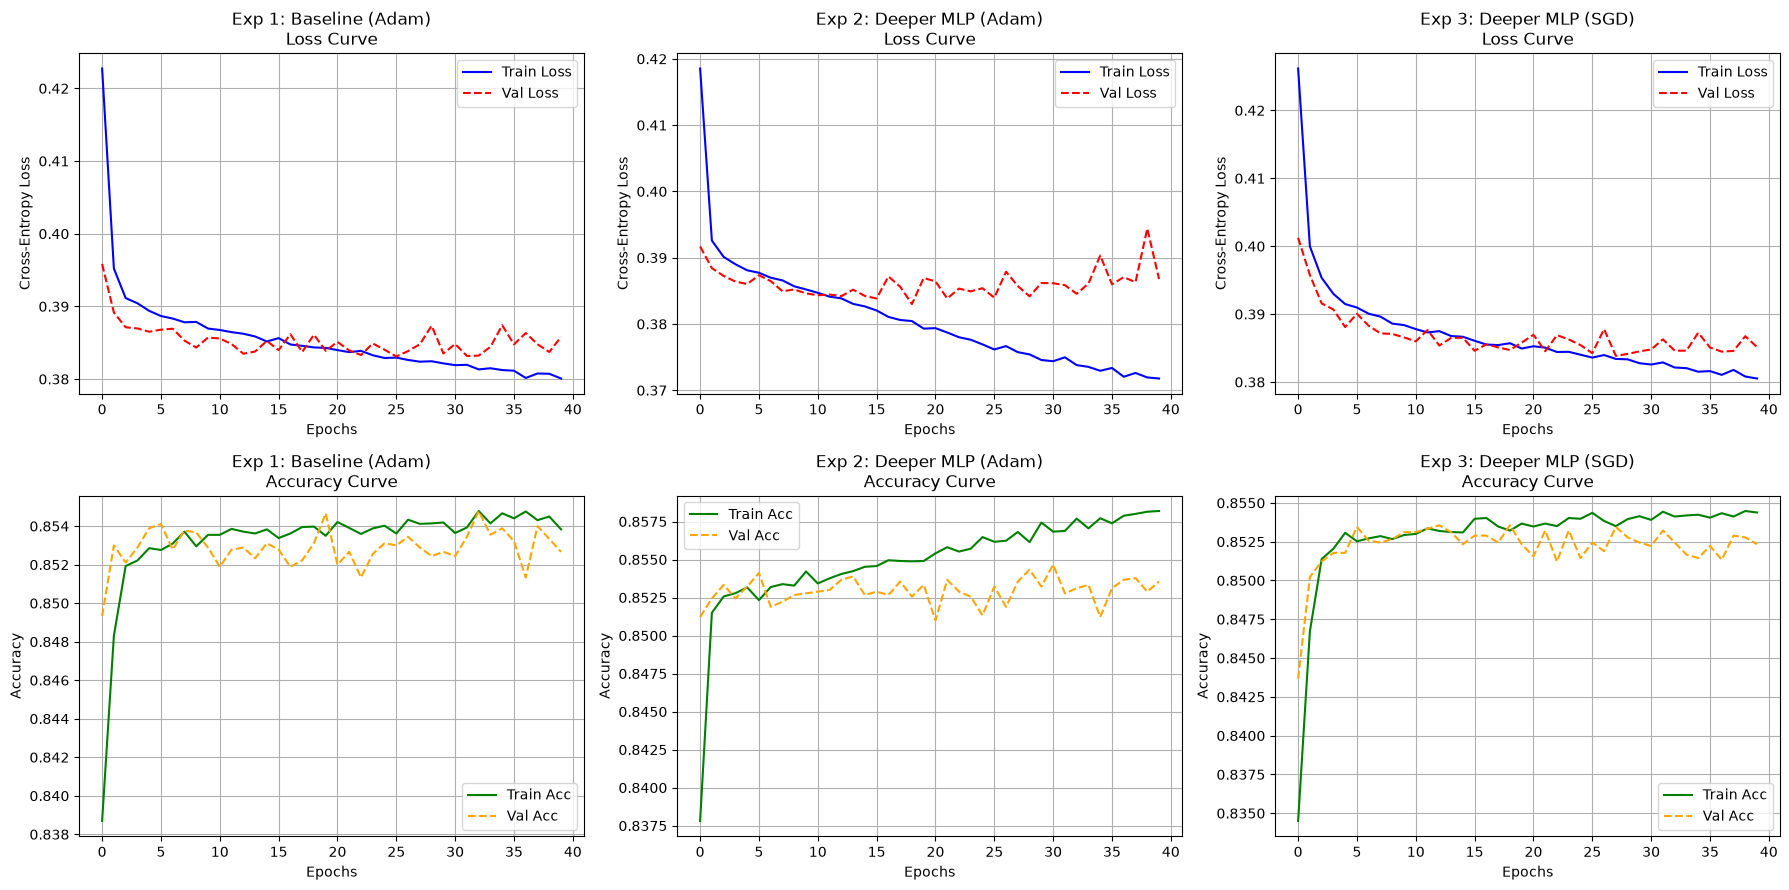

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

experiments = [
    ("Exp 1: Baseline (Adam)", history_exp1),
    ("Exp 2: Deeper MLP (Adam)", history_exp2),
    ("Exp 3: Deeper MLP (SGD)", history_exp3)
]

for idx, (title, hist) in enumerate(experiments):
    # Đường cong Cross-Entropy Loss
    axes[0, idx].plot(hist['train_loss'], label='Train Loss', color='blue')
    axes[0, idx].plot(hist['val_loss'], label='Val Loss', color='red', linestyle='--')
    axes[0, idx].set_title(f"{title}\nLoss Curve")
    axes[0, idx].set_xlabel("Epochs")
    axes[0, idx].set_ylabel("Cross-Entropy Loss")
    axes[0, idx].legend()
    axes[0, idx].grid(True)
    
    # Đường cong Accuracy
    axes[1, idx].plot(hist['train_acc'], label='Train Acc', color='green')
    axes[1, idx].plot(hist['val_acc'], label='Val Acc', color='orange', linestyle='--')
    axes[1, idx].set_title(f"{title}\nAccuracy Curve")
    axes[1, idx].set_xlabel("Epochs")
    axes[1, idx].set_ylabel("Accuracy")
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

## Đánh giá chi tiết trên tập Test và hiển thị Confusion Matrix

=== BẢNG TỔNG HỢP HIỆU NĂNG KHAI PHÁ SỞ THÍCH TRÊN TẬP TEST ===
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Baseline MLP (Adam)    0.8454     0.8573  0.9782    0.9138   0.7176
  Deeper MLP (Adam)    0.8456     0.8558  0.9808    0.9140   0.7093
   Deeper MLP (SGD)    0.8472     0.8551  0.9843    0.9151   0.7113


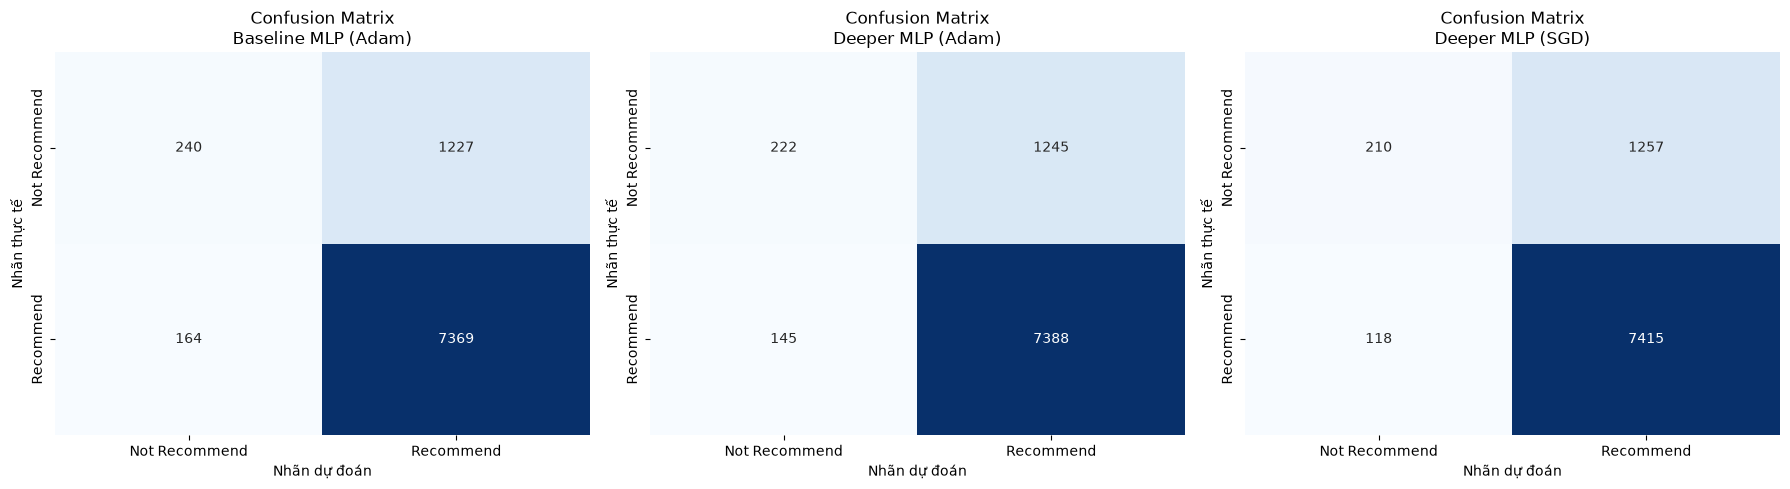

In [10]:
def compute_classification_metrics(model, X_arr, y_true, device):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_arr).to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    
    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary', zero_division=0)
    auc = roc_auc_score(y_true, probs[:, 1])
    return acc, precision, recall, f1, auc, preds

models = {
    "Baseline MLP (Adam)": model_exp1,
    "Deeper MLP (Adam)": model_exp2,
    "Deeper MLP (SGD)": model_exp3
}

results = []
preds_dict = {}
for name, m in models.items():
    acc, prec, rec, f1, auc, preds = compute_classification_metrics(m, X_test, y_test, device)
    preds_dict[name] = preds
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC-ROC": round(auc, 4)
    })

print("=== BẢNG TỔNG HỢP HIỆU NĂNG KHAI PHÁ SỞ THÍCH TRÊN TẬP TEST ===")
print(pd.DataFrame(results).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Not Recommend', 'Recommend']

for idx, (name, _) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds_dict[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(f"Confusion Matrix\n{name}")
    axes[idx].set_xlabel("Nhãn dự đoán")
    axes[idx].set_ylabel("Nhãn thực tế")

plt.tight_layout()
plt.show()

## Khám phá tầng biểu diễn ẩn (Learned Representation)

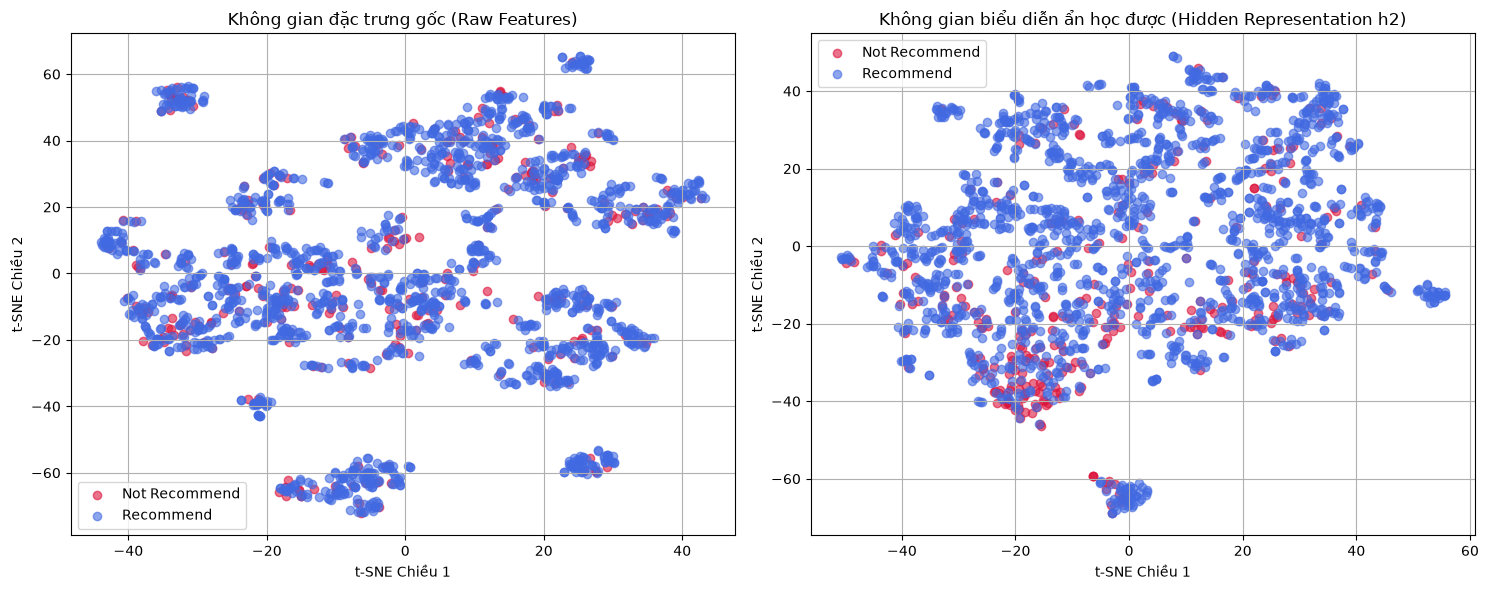

In [11]:
from sklearn.manifold import TSNE

# Lấy 2.000 mẫu ngẫu nhiên trên tập kiểm thử để giảm chiều t-SNE
sample_size = min(2000, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

X_sub = torch.tensor(X_test[sample_indices]).to(device)
y_sub = y_test[sample_indices]

with torch.no_grad():
    h_sub = model_exp2.get_representation(X_sub).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
raw_2d = tsne.fit_transform(X_test[sample_indices])
h_2d = tsne.fit_transform(h_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(raw_2d[y_sub == 0, 0], raw_2d[y_sub == 0, 1], color='crimson', alpha=0.6, label='Not Recommend')
axes[0].scatter(raw_2d[y_sub == 1, 0], raw_2d[y_sub == 1, 1], color='royalblue', alpha=0.6, label='Recommend')
axes[0].set_title("Không gian đặc trưng gốc (Raw Features)")
axes[0].set_xlabel("t-SNE Chiều 1")
axes[0].set_ylabel("t-SNE Chiều 2")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(h_2d[y_sub == 0, 0], h_2d[y_sub == 0, 1], color='crimson', alpha=0.6, label='Not Recommend')
axes[1].scatter(h_2d[y_sub == 1, 0], h_2d[y_sub == 1, 1], color='royalblue', alpha=0.6, label='Recommend')
axes[1].set_title("Không gian biểu diễn ẩn học được (Hidden Representation h2)")
axes[1].set_xlabel("t-SNE Chiều 1")
axes[1].set_ylabel("t-SNE Chiều 2")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Đóng gói và lưu trữ mô hình

In [12]:
BEST_SEPHORA_MODEL = "sephora_preference_mlp_best.pth"

# Lưu lại trọng số của mô hình tối ưu (Exp 2 - Deeper MLP)
torch.save(model_exp2.state_dict(), BEST_SEPHORA_MODEL)
print(f"Đã lưu trọng số mô hình tốt nhất thành công vào: {BEST_SEPHORA_MODEL}")

# Khởi tạo mô hình mới và nạp lại để xác nhận tính toàn vẹn
loaded_pref_model = DeeperPreferenceMLP()
loaded_pref_model.load_state_dict(torch.load(BEST_SEPHORA_MODEL))
loaded_pref_model.eval()
print("Mô hình đã được nạp lại thành công và sẵn sàng suy luận!")

Đã lưu trọng số mô hình tốt nhất thành công vào: sephora_preference_mlp_best.pth
Mô hình đã được nạp lại thành công và sẵn sàng suy luận!
